# import library

In [1]:
!pip install scikit-surprise

In [2]:
!pip install numpy==1.26.4

In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

sns.set_theme(style="whitegrid")

In [4]:
import glob
import kagglehub
from kagglehub import KaggleDatasetAdapter
from google.colab import files

# Config

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cell di bawah jangan di run error

In [ ]:
# 1. Tentukan lokasi folder di Google Drive
folder_path = '/content/drive/MyDrive/Dataset_IMDB/'

# 2. Cari semua file yang berakhiran .json di dalam folder tersebut
# (Kita asumsikan Anda hanya ingin mengambil file 'part-XX.json')
file_list = glob.glob(folder_path + "part-*.json")

# 3. Baca dan gabungkan semua file
dataframes = []
for file in file_list:
    # Catatan: Jika formatnya adalah JSON Lines (1 baris = 1 JSON), tambahkan parameter lines=True
    # df = pd.read_json(file, lines=True)
    df = pd.read_json(file)
    dataframes.append(df)

# Gabungkan semuanya menjadi satu DataFrame utama
df_imdb = pd.concat(dataframes, ignore_index=True)

# 4. Tampilkan 5 baris pertama untuk memastikan data sudah masuk
df_imdb.head()

Jika data sample sudah selesai dan code keselurah sudah selesai.

# Data Loading

In [8]:
json_data = pd.read_json("/content/drive/MyDrive/Dataset_IMDB/sample.json")

In [9]:
# store in a new variable as we'll mutate it
sample_df = json_data
# let's modify the data to add more useful information for later
sample_df[["helpful_yes", "helpful_plus_not_helpful"]] = sample_df['helpful'].apply(pd.Series)
# casting from original strings to ints, but before that removing the "," as there are some big numbers like "1,264" causing issues
sample_df["helpful_yes"] = sample_df["helpful_yes"].str.replace(',', '').astype("int16")
sample_df["helpful_plus_not_helpful"] = sample_df["helpful_plus_not_helpful"].str.replace(',', '').astype("int16")
sample_df["helpful_ratio"] = sample_df["helpful_yes"] / sample_df["helpful_plus_not_helpful"]
# and let's check the data
display(sample_df.head())
display(sample_df.describe(include="all"))
print(sample_df.info(memory_usage="deep"))
print(sample_df.shape)

,review_id,reviewer,movie,rating,review_summary,review_date,spoiler_tag,review_detail,helpful,helpful_yes,helpful_plus_not_helpful,helpful_ratio
0,rw1133942,OriginalMovieBuff21,Kill Bill: Vol. 2 (2004),8.0,Good follow up that answers all the questions,24 July 2005,0,"After seeing Tarantino's Kill Bill Vol: 1, I g...","[0, 1]",0,1,0.000000
1,rw1133943,sentra14,Journey to the Unknown (1968– ),NaN,Excellent series,24 July 2005,0,"I have the entire series on video, taped mostl...","[11, 11]",11,11,1.000000
2,rw1133946,GreenwheelFan2002,The Island (2005),9.0,"Not just about action, but about survival...",24 July 2005,0,Once again the critics prove themselves as mor...,"[2, 5]",2,5,0.400000
3,rw1133948,itsascreambaby,Win a Date with Tad Hamilton! (2004),3.0,Falls under the category: seen it a million ti...,24 July 2005,0,This IS a film that has been done too many tim...,"[2, 3]",2,3,0.666667
4,rw1133949,OriginalMovieBuff21,Saturday Night Live: The Best of Chris Farley ...,10.0,"Before Tommy Boy and Black Sheep, there was Sa...",24 July 2005,0,Chris Farley is one of my favorite comedians a...,"[4, 4]",4,4,1.000000


,review_id,reviewer,movie,rating,review_summary,review_date,spoiler_tag,review_detail,helpful,helpful_yes,helpful_plus_not_helpful,helpful_ratio
count,100000,100000,100000,87908.000000,100000,100000,100000.00000,100000,100000,100000.000000,100000.000000,95148.000000
unique,99998,52651,29192,NaN,92704,166,NaN,99937,4584,NaN,NaN,NaN
top,rw1199445,lee_eisenberg,Harry Potter and the Goblet of Fire (2005),NaN,My brief review of the film,27 November 2005,NaN,I thought that the characters were really funn...,"[0, 1]",NaN,NaN,NaN
freq,2,542,1285,NaN,234,787,NaN,16,6063,NaN,NaN,NaN
mean,NaN,NaN,NaN,6.997645,NaN,NaN,0.22580,NaN,NaN,9.330960,15.348840,0.516153
std,NaN,NaN,NaN,2.892952,NaN,NaN,0.41811,NaN,NaN,30.257168,43.150368,0.294273
min,NaN,NaN,NaN,1.000000,NaN,NaN,0.00000,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,5.000000,NaN,NaN,0.00000,NaN,NaN,1.000000,3.000000,0.333333
50%,NaN,NaN,NaN,8.000000,NaN,NaN,0.00000,NaN,NaN,3.000000,6.000000,0.500000
75%,NaN,NaN,NaN,10.000000,NaN,NaN,0.00000,NaN,NaN,8.000000,15.000000,0.750000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   review_id                 100000 non-null  object 
 1   reviewer                  100000 non-null  object 
 2   movie                     100000 non-null  object 
 3   rating                    87908 non-null   float64
 4   review_summary            100000 non-null  object 
 5   review_date               100000 non-null  object 
 6   spoiler_tag               100000 non-null  int64  
 7   review_detail             100000 non-null  object 
 8   helpful                   100000 non-null  object 
 9   helpful_yes               100000 non-null  int16  
 10  helpful_plus_not_helpful  100000 non-null  int16  
 11  helpful_ratio             95148 non-null   float64
dtypes: float64(2), int16(2), int64(1), object(7)
memory usage: 181.0 MB
None
(100000, 12)


# Data Preprocessing

In [10]:
# Menghapus baris yang nilai 'rating'-nya kosong (NaN)
df_clean = sample_df.dropna(subset=['rating']).copy()

In [11]:
# Mengambil kolom reviewer, movie, dan rating saja
df_recsys = df_clean[['reviewer', 'movie', 'rating']]

In [12]:
# Menggabungkan duplikat reviewer dan movie dengan mengambil nilai rata-rata ratingnya
df_recsys = df_recsys.groupby(['reviewer', 'movie'])['rating'].mean().reset_index()

In [13]:
# Mengecek nilai yang kosong
df_recsys.isnull().sum()

,0
reviewer,0
movie,0
rating,0


In [14]:
# Mengecek duplikasi data
df_recsys.duplicated().sum()

0

In [15]:
df_recsys.head()

,reviewer,movie,rating
0,*(CableGuy)*,The Musketeer (2001),2.0
1,-628,Oyster Farmer (2004),7.0
2,-628,The Adventures of Sharkboy and Lavagirl 3-D (2...,6.0
3,-628,Wolf Creek (2005),6.0
4,-Peter-,Leaving Las Vegas (1995),9.0


Lanjutan preprocessing dari df_recsys setalah EDA

In [16]:
# Tentukan batas minimum rating per user
min_ratings = 3

# Ambil daftar user yang jumlah ratingnya memenuhi syarat
user_counts = df_recsys['reviewer'].value_counts()
active_users = user_counts[user_counts >= min_ratings].index

# Filter dataset hanya untuk user yang aktif tersebut
df_filtered = df_recsys[df_recsys['reviewer'].isin(active_users)].copy()

# EDA (Exploratory Data Analysis)


In [17]:
# Menghitung jumlah user dan item unik
num_users = df_filtered['reviewer'].nunique()
num_movies = df_filtered['movie'].nunique()

print(f"Jumlah User Unik: {num_users}")
print(f"Jumlah Film Unik: {num_movies}")

# Melihat distribusi rating
print("\nDistribusi Nilai Rating:")
print(df_filtered['rating'].value_counts().sort_index())

Jumlah User Unik: 3977
Jumlah Film Unik: 16138

Distribusi Nilai Rating:
rating
1.0     1986
2.0     1360
3.0     1661
4.0     2093
5.0     3068
6.0     4415
7.0     6576
8.0     7390
9.0     4908
10.0    6876
Name: count, dtype: int64


/tmp/ipykernel_7969/3991576794.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtered, x='rating', palette='viridis')


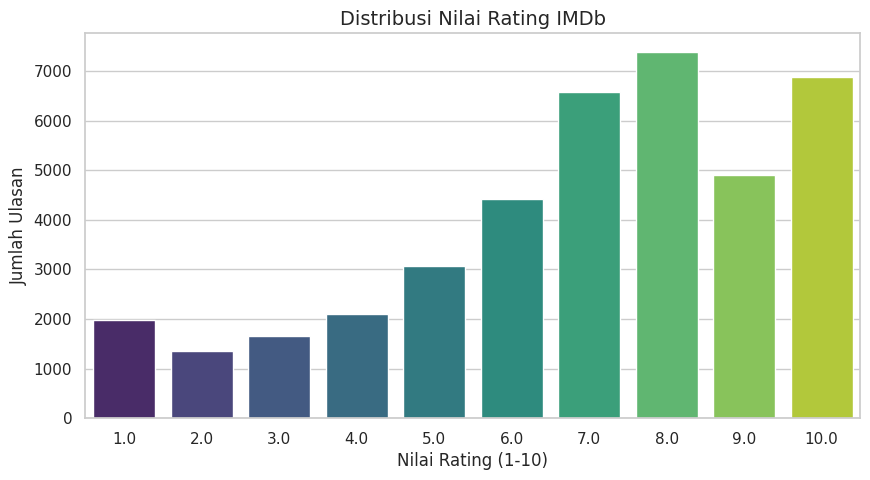

Rata-rata rating keseluruhan: 6.89


In [18]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_filtered, x='rating', palette='viridis')
plt.title('Distribusi Nilai Rating IMDb', fontsize=14)
plt.xlabel('Nilai Rating (1-10)')
plt.ylabel('Jumlah Ulasan')
plt.show()

# Melihat nilai rata-rata keseluruhan
global_mean = df_filtered['rating'].mean()
print(f"Rata-rata rating keseluruhan: {global_mean:.2f}")

User lebih suka memberi ulasan pada film yang disukai jika rentang yang lebih tinggi 8, 9, 10

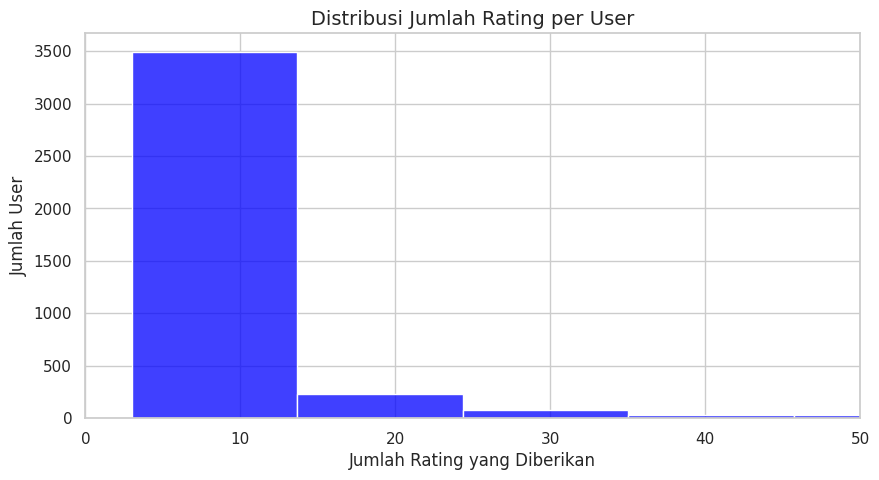

User paling aktif memberikan 537 rating.
Rata-rata rating per user: 10.14
Jumlah user yang hanya memberi 1 rating: 0


In [19]:
# Menghitung berapa banyak rating yang diberikan tiap user
user_counts = df_filtered['reviewer'].value_counts()

plt.figure(figsize=(10, 5))
sns.histplot(user_counts, bins=50, kde=False, color='blue')
plt.title('Distribusi Jumlah Rating per User', fontsize=14)
plt.xlabel('Jumlah Rating yang Diberikan')
plt.ylabel('Jumlah User')
plt.xlim(0, 50) # Membatasi tampilan X agar fokus pada mayoritas
plt.show()

print(f"User paling aktif memberikan {user_counts.max()} rating.")
print(f"Rata-rata rating per user: {user_counts.mean():.2f}")
print(f"Jumlah user yang hanya memberi 1 rating: {(user_counts == 1).sum()}")

Rata Rata User memberikan rating pada film

/tmp/ipykernel_7969/1175197416.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=movie_counts.index[:10], x=movie_counts.values[:10], palette='magma')


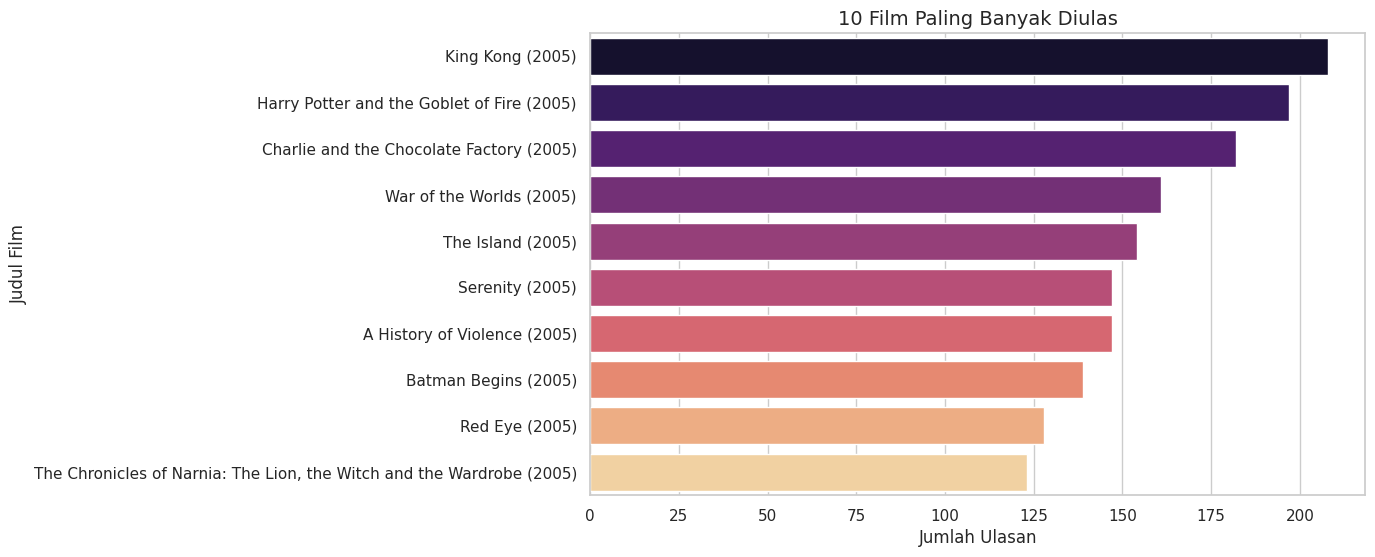

Film paling populer mendapat 208 rating.
Jumlah film yang hanya memiliki 1 rating: 10236


In [20]:
# Menghitung berapa banyak rating yang didapat tiap film
movie_counts = df_filtered['movie'].value_counts()

# Menampilkan 10 film paling banyak diulas
plt.figure(figsize=(10, 6))
sns.barplot(y=movie_counts.index[:10], x=movie_counts.values[:10], palette='magma')
plt.title('10 Film Paling Banyak Diulas', fontsize=14)
plt.xlabel('Jumlah Ulasan')
plt.ylabel('Judul Film')
plt.show()

print(f"Film paling populer mendapat {movie_counts.max()} rating.")
print(f"Jumlah film yang hanya memiliki 1 rating: {(movie_counts == 1).sum()}")

In [21]:
total_users = df_filtered['reviewer'].nunique()
total_movies = df_filtered['movie'].nunique()
total_ratings = len(df_filtered)

sparsity = 1 - (total_ratings / (total_users * total_movies))

print(f"Total Users: {total_users}")
print(f"Total Movies: {total_movies}")
print(f"Sparsity Matriks: {sparsity * 100:.4f}%")

Total Users: 3977
Total Movies: 16138
Sparsity Matriks: 99.9372%


# Model Training

In [22]:
# Memberi tahu model bahwa skala rating kita dari 1 hingga 10
reader = Reader(rating_scale=(1, 10))

In [23]:
# Memuat urutan column reviewer, movie, rating
data = Dataset.load_from_df(df_filtered[['reviewer', 'movie', 'rating']], reader)

## KNN

In [24]:
from surprise import SVD, SVDpp, KNNWithMeans, BaselineOnly, CoClustering
from surprise.model_selection import cross_validate
import pandas as pd

# Inisialisasi daftar algoritma yang bervariasi
algorithms = [
    SVD(), # Matrix Factorization klasik
    SVDpp(), # Biasanya lebih akurat dari SVD tapi proses training lebih lama
    KNNWithMeans(sim_options={'name': 'pearson_baseline', 'user_based': False}), # Item-based Collaborative Filtering
    BaselineOnly(), # Model sederhana sebagai pembanding
    CoClustering()
]

benchmark_results = []

In [25]:
for algo in algorithms:
    print(f"Sedang training {algo.__class__.__name__}...")

    # K-Fold Cross Validation (cv=5)
    results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)

    benchmark_results.append({
        'Algoritma': algo.__class__.__name__,
        'RMSE': results['test_rmse'].mean(),
        'MAE': results['test_mae'].mean(),
        'Waktu Training': sum(results['fit_time']) / 5
    })

# Tampilkan hasil komparasi
df_knn = pd.DataFrame(benchmark_results).sort_values(by='RMSE')
print(df_knn)

Sedang training SVD...
Sedang training SVDpp...
Sedang training KNNWithMeans...
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Sedang training BaselineOnly...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Sedang training CoClustering...
      Algoritma      RMSE       MAE  Waktu Training
0           SVD  2.229422  1.738874        0.631882
3  BaselineO

In [26]:
from surprise.model_selection import GridSearchCV

# Menentukan grid hyperparameter yang akan diuji
# Sesuaikan rentang ini jika komputasi terlalu berat
param_grid = {
    'n_epochs': [20, 30, 40],        # Jumlah iterasi SGD
    'lr_all': [0.002, 0.005, 0.01],  # Learning rate
    'reg_all': [0.02, 0.05, 0.1]     # Regularization term untuk mencegah overfitting
}

print("Memulai pencarian hyperparameter terbaik...")
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=5, n_jobs=-1) # n_jobs=-1 agar menggunakan semua core CPU
gs.fit(data)

print(f"RMSE Terbaik: {gs.best_score['rmse']:.4f}")
print(f"Parameter Terbaik: {gs.best_params['rmse']}")

# Ambil model terbaiknya untuk digunakan nanti
best_svd_model = gs.best_estimator['rmse']

Memulai pencarian hyperparameter terbaik...
RMSE Terbaik: 2.2035
Parameter Terbaik: {'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1}


In [27]:
# Build full trainset dari keseluruhan data
trainset = data.build_full_trainset()

# Train model terbaik dari GridSearchCV
best_svd_model.fit(trainset)

## Random Forest

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# Gunakan dataframe asli kamu
df_rf = df_filtered[['reviewer', 'movie', 'rating']].copy()

# Inisialisasi encoder
le_user = LabelEncoder()
le_movie = LabelEncoder()

# Transformasi ID menjadi angka (0, 1, 2, dst.)
df_rf['reviewer_encoded'] = le_user.fit_transform(df_rf['reviewer'])
df_rf['movie_encoded'] = le_movie.fit_transform(df_rf['movie'])

# Tentukan Fitur (X) dan Target (y)
X = df_rf[['reviewer_encoded', 'movie_encoded']]
y = df_rf['rating']

# Membagi dataset: 80% untuk training, 20% untuk testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None, # Biarkan pohon tumbuh maksimal (bisa di-tune nanti jika overfitting)
    random_state=42,
    n_jobs=-1
)

# Proses Training
rf_model.fit(X_train, y_train)
print("Training selesai!")

Training selesai!


# Evaluasi Model

## KNN

In [30]:
from surprise.model_selection import train_test_split as surprise_train_test_split
from sklearn.metrics import f1_score

# 1. Split data untuk Surprise
trainset, testset = surprise_train_test_split(data, test_size=0.2, random_state=42)

# 2. Latih ulang model SVD terbaik pada trainset
best_svd_model.fit(trainset)

# 3. Lakukan prediksi pada testset
svd_predictions = best_svd_model.test(testset)

# 4. Tentukan Threshold
THRESHOLD = 4.0

# 5. Konversi rating asli dan hasil prediksi ke biner (1 atau 0)
# pred.r_ui adalah rating asli, pred.est adalah rating prediksi dari model
y_true_svd = [1 if pred.r_ui >= THRESHOLD else 0 for pred in svd_predictions]
y_pred_svd = [1 if pred.est >= THRESHOLD else 0 for pred in svd_predictions]

# 6. Hitung F1 Score
f1_svd = f1_score(y_true_svd, y_pred_svd)
print(f"F1-Score SVD: {f1_svd:.4f}")

F1-Score SVD: 0.9340


In [31]:
user_id = 'user_001'
movie_id = 'movie_105'
prediction = best_svd_model.predict(user_id, movie_id)

print(f"Prediksi rating dari {user_id} untuk {movie_id}: {prediction.est:.2f}")

Prediksi rating dari user_001 untuk movie_105: 6.89


## Random Forest

In [32]:
import numpy as np


# Lakukan prediksi pada data testing
y_pred = rf_model.predict(X_test)

# Hitung metrik evaluasi
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Random Forest RMSE: {rmse:.4f}")
print(f"Random Forest MAE: {mae:.4f}")

Random Forest RMSE: 2.5404
Random Forest MAE: 1.9823


In [33]:
# Tentukan Threshold yang sama
THRESHOLD = 4.0

# 1. Konversi y_test (rating aktual) menjadi biner
y_true_rf = [1 if rating >= THRESHOLD else 0 for rating in y_test]

# 2. Konversi y_pred (rating prediksi dari Random Forest) menjadi biner
y_pred_rf = [1 if rating >= THRESHOLD else 0 for rating in y_pred]

# 3. Hitung F1 Score
f1_rf = f1_score(y_true_rf, y_pred_rf)
print(f"F1-Score Random Forest: {f1_rf:.4f}")

F1-Score Random Forest: 0.9264


# Saved Model

In [ ]:
import json

model_data = {
    "global_mean": best_svd_model.trainset.global_mean,

    # Bias user dan movie
    "bu": best_svd_model.bu.tolist(),
    "bi": best_svd_model.bi.tolist(),

    # Faktor latent (matriks SVD)
    "pu": best_svd_model.pu.tolist(),
    "qi": best_svd_model.qi.tolist(),

    "user_mapping": {best_svd_model.trainset.to_raw_uid(i): i for i in best_svd_model.trainset.all_users()},
    "movie_mapping": {best_svd_model.trainset.to_raw_iid(i): i for i in best_svd_model.trainset.all_items()}
}

# Simpan ke JSON
with open('svd_weights.json', 'w') as f:
    json.dump(model_data, f)

print("Berhasil diekspor ke svd_weights.json!")

# TensorFlow js